In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('./processed/dataset.csv')
print(data)

       Unnamed: 0             datetime     speed     power    price  \
0               0  2020-01-01 01:00:00  7.194702  10827.38  13.6875   
1               1  2020-01-01 02:00:00  7.516418  11527.36  13.2450   
2               2  2020-01-01 03:00:00  7.272845  12100.85  11.3500   
3               3  2020-01-01 04:00:00  7.192857  12780.48   9.3925   
4               4  2020-01-01 05:00:00  7.382434  13064.80   8.6050   
...           ...                  ...       ...       ...      ...   
43838       43838  2024-12-31 20:00:00  3.905590   2678.47  50.1650   
43839       43839  2024-12-31 21:00:00  3.856292   4396.05  31.5675   
43840       43840  2024-12-31 22:00:00  3.379553   5852.33  26.8350   
43841       43841  2024-12-31 23:00:00  3.468478   7239.34  22.4650   
43842       43842  2024-12-31 24:00:00  6.660651       NaN  20.2875   

              load  
0      1172.943179  
1      1165.951313  
2      1149.076769  
3      1141.301918  
4      1147.094161  
...            ...  


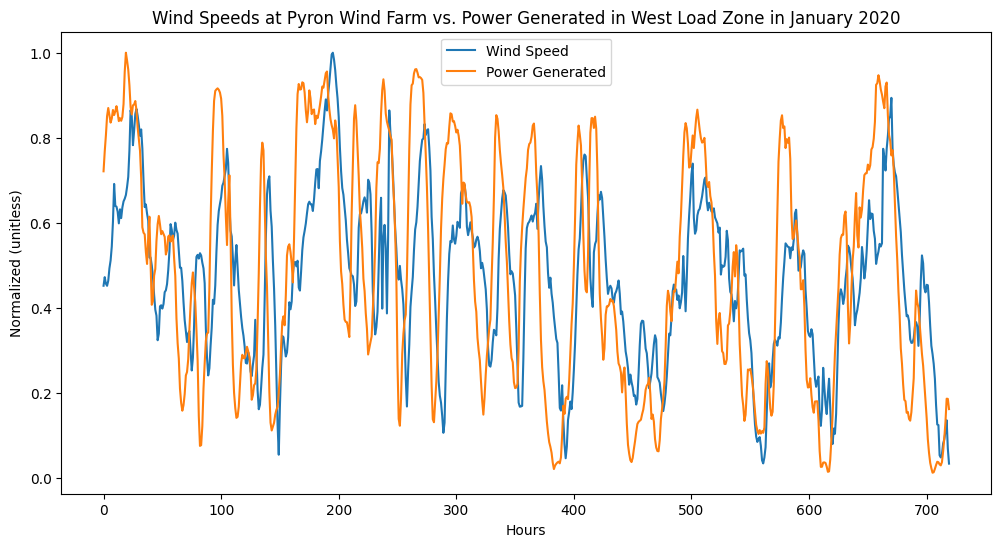

In [10]:
idxs2020 = (0,8783)
idxs2021 = (8784, 17543)
idxs2022 = (17544, 26303)
idxs2023 = (26304, 35063)
idxs2024 = (35064, -1)

speeds = data['speed']
powers = data['power']

idx1mo = 24*30
speeds1mo = speeds[0:idx1mo]
powers1mo = powers[0:idx1mo]

# Normalize for rescaling purposes
powers1mo /= np.max(powers1mo)
speeds1mo /= np.max(speeds1mo)

plt.figure(figsize=(12, 6)) 
plt.plot(np.arange(0, idx1mo), speeds1mo, label='Wind Speed')
plt.plot(np.arange(0, idx1mo), powers1mo, label='Power Generated')
plt.ylabel('Normalized (unitless)')
plt.xlabel('Hours')
plt.title('Wind Speeds at Pyron Wind Farm vs. Power Generated in West Load Zone in January 2020')
plt.legend()
plt.show()

In [4]:
idxs2020 = (0,8783)
idxs2021 = (8784, 17543)
idxs2022 = (17544, 26303)
idxs2023 = (26304, 35063)
idxs2024 = (35064, -1)

speeds = data['speed']
powers = data['power']

idx1mo = 24*30
speeds1mo = speeds[0:idx1mo]
powers1mo = powers[0:idx1mo]

# Normalize for rescaling purposes
powers1mo /= np.max(powers1mo)
speeds1mo /= np.max(speeds1mo)

plt.figure(figsize=(12, 6)) 
plt.plot(np.arange(0, idx1mo - 6), speeds1mo[6:], label='Wind Speed')
plt.plot(np.arange(0, idx1mo - 6), powers1mo[:-6], label='Power Generated')
plt.ylabel('Normalized (unitless)')
plt.xlabel('Hours')
plt.title('Wind Speeds at Pyron Wind Farm vs. Power Generated in West Load Zone in January 2020')
plt.legend()
plt.show()

NameError: name 'data' is not defined

In [ ]:
df = pd.read_csv('./processed/dataset_2018-21.csv')

[]

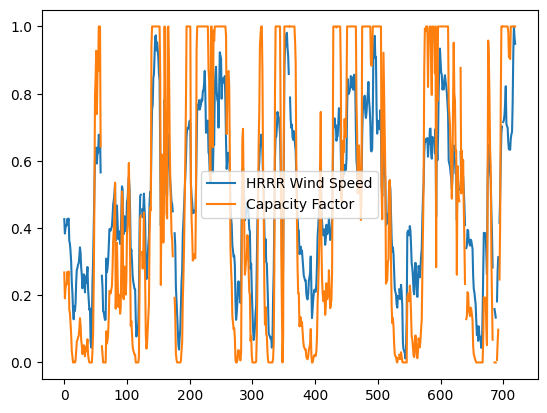

In [7]:
idx1mo = 24 * 30

speed = df['speed_HRRR']
cf = df['power_cf']
price = df['lmp']

norm_speed = speed / np.max(speed[:idx1mo])

x = np.arange(0, idx1mo)
plt.plot(x, norm_speed[:idx1mo], label='HRRR Wind Speed')
plt.plot(x, cf[:idx1mo], label='Capacity Factor')
plt.legend()
plt.plot()

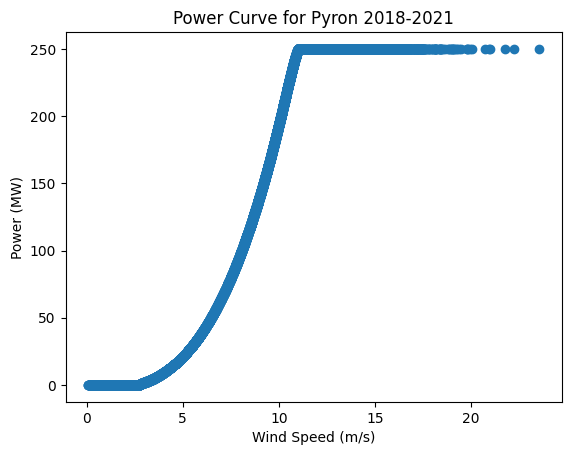

In [10]:
rated_capacity = 250

power = cf * rated_capacity
plt.scatter(speed, power)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Power Curve for Pyron 2018-2021')
plt.show()